# Applying ML models for stock returns prediction

## Initialization

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor

In [107]:
tickers = ["JNJ", "AAPL", "MSFT", "PG", "KO"]

start = "2017-01-01"
end = "2020-12-31"

stock_data = {}

In [108]:
# Download market indext data for S&P 500 index ticker
sp500 = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)
sp500.columns = sp500.columns.droplevel(1)
sp500_market_return = sp500['Close'].pct_change().to_frame(name='market_return')

In [109]:
# Download stock data for each ticker and store it in a dictionary
for ticker in tickers:
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    # Drop stock name level from columns
    df.columns = df.columns.droplevel(1)
    # Ensure datetime index and sort by date
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    # Calculate stock returns variable
    df['stock_return'] = df['Close'].pct_change()
    # Add market indext return to the stock data
    df = df.merge(sp500_market_return, left_index=True, right_index=True, how='inner')
    # Add the stock data to the dictionary
    stock_data[ticker] = df

df = stock_data['AAPL']
df

,Close,High,Low,Open,Volume,stock_return,market_return
Date,,,,,,,
2017-01-03,26.745855,26.787304,26.425780,26.665261,115127600,NaN,NaN
2017-01-04,26.715918,26.828751,26.653745,26.676772,84472400,-0.001119,0.005722
2017-01-05,26.851778,26.909346,26.667561,26.692891,88774400,0.005085,-0.000771
2017-01-06,27.151129,27.208696,26.819540,26.890923,127007600,0.011148,0.003517
2017-01-09,27.399824,27.501143,27.158042,27.160343,134247600,0.009160,-0.003549
...,...,...,...,...,...,...,...
2020-12-23,127.364136,128.793759,127.189070,128.531183,88223700,-0.006976,0.000746
2020-12-24,128.346405,129.795498,127.500298,127.714258,54930100,0.007712,0.003537
2020-12-28,132.936798,133.568945,129.844106,130.310937,124486200,0.035766,0.008723


## Preprocessing, Feature Engineering, Train/Test Spliting

### Preprocessing Functions

In [110]:
def handle_outliers_winsorize(df, col, lower_q=0.01, upper_q=0.99):
    lower = df[col].quantile(lower_q)
    upper = df[col].quantile(upper_q)
    df[col] = df[col].clip(lower, upper)
    return df

### Feature Engineering Functions

In [111]:
def add_moving_average(df, n, price_col='Close'):
    """
    Calculate n-day Simple Moving Average (SMA) on a financial time series.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing price data
    n : int
        Window size (e.g., 10, 50, 200)
    price_col : str
        Column name to calculate SMA on (default: 'Close')

    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with new SMA column added
    """
    
    df[f'SMA_{n}'] = df[price_col].rolling(window=n, min_periods=n).mean()
    return df

def add_volatility(df, n=20, price_col='Close', annualize=False):
    """
    Add an n-day rolling volatility feature based on past returns.

    This is a rolling-window feature engineering step:
    - returns describe day-to-day price changes
    - rolling std of returns estimates recent noise / uncertainty
    - if annualize=True, daily volatility is scaled by sqrt(252)

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing price data.
    n : int
        Rolling window size.
    price_col : str, default='Close'
        Column used to compute returns.
    annualize : bool, default=False
        If True, annualise daily volatility using sqrt(252).

    Returns
    -------
    pandas.DataFrame
        Copy of df with:
        - 'return'
        - f'volatility_{n}' (or annualised version)
    """

    # Rolling volatility = recent standard deviation of returns
    vol_col = f'volatility_{n}'
    df[vol_col] = df['stock_return'].rolling(window=n, min_periods=n).std()

    # Optional annualisation for finance applications
    if annualize:
        df[vol_col] = df[vol_col] * np.sqrt(252)

    return df

def add_momentum_rsi(df, n=14, price_col='Close', col_name=None):
    """
    Adds Relative Strength Index (RSI) feature to dataframe.

    Parameters:
    - df: pandas DataFrame
    - n: lookback window (default = 14, standard in finance)
    - price_col: column name for price (default = 'Close')
    - col_name: optional custom column name

    Returns:
    - df with RSI column added
    """
    
    if col_name is None:
        col_name = f'RSI_{n}'
    
    # Price changes (returns in price space, not percentage)
    delta = df[price_col].diff()

    # Gains and losses
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    gain = pd.Series(gain, index=df.index)
    loss = pd.Series(loss, index=df.index)

    # Rolling averages (Wilder's smoothing approximation using mean)
    avg_gain = gain.rolling(window=n, min_periods=n).mean()
    avg_loss = loss.rolling(window=n, min_periods=n).mean()

    # Avoid division by zero
    rs = avg_gain / (avg_loss + 1e-10)

    # RSI formula
    rsi = 100 - (100 / (1 + rs))

    df[col_name] = rsi

    return df

In [112]:
# Step 1 (Load Data): Load historical stock data

# Handle initiall missing values (calendar gaps) using forward fill
df['Close'].fillna(method='ffill', inplace=True) 
# Log-transform the Volume to reduce skewness
df['Volume'] = np.log1p(df['Volume'])

# Step 2 (Feature Engineering): Compute technical indicators
add_moving_average(df,10)
add_moving_average(df,50)
add_moving_average(df,200)
add_volatility(df)
add_momentum_rsi(df)

# Extra features 
def extra_featires(data):

    # Moving Average Convergence Divergence (MACD)
    data['MACD'] = data['Close'].ewm(span=12, adjust=False).mean() - data['Close'].ewm(span=26, adjust=False).mean()

    # Bollinger Bands
    data['Rolling_std'] = data['Close'].rolling(window=10, min_periods=1).std()
    data['BB_Upper'] = data['SMA_10'] + 2 * data['Rolling_std']
    data['BB_Lower'] = data['SMA_10'] - 2 * data['Rolling_std']

    # Average True Range (ATR)
    high_low = data['High'] - data['Low']
    high_close = (data['High'] - data['Close'].shift()).abs()
    low_close = (data['Low'] - data['Close'].shift()).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1)
    data['ATR'] = true_range.max(axis=1).rolling(window=14, min_periods=1).mean()
    return data

extra_featires(df)
# Step 3: Define Features and Target Variable
# X = df.drop(columns=['Close', 'Open', 'High', 'Low'])
X = df
y = df['stock_return'].shift(-1).to_frame(name='target')
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# Step 4: Clean the Data
# 4.1. Handling Outliers
handle_outliers_winsorize(X,'stock_return')
handle_outliers_winsorize(X,'market_return')

# 4.2. Handling Type (Convert all columns to numeric (forcing errors to NaN))
X = X.apply(pd.to_numeric, errors='coerce')

# 4.3. Handling Infinities (Replace infinities with NaN)
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# 4.4. Re-indexing (Reset index before dropping NaNs to avoid index misalignment)
X.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)

# 4.5. Handling Missing Values (Drop rows with NaN values in X and align y accordingly)
X.dropna(inplace=True)
y = y.loc[X.index]

# Drop NaNs in y (shift(-1) creates NaN at the last row; missing Close values can create more)
y.dropna(inplace=True)
X = X.loc[y.index]

# Step 5 Train-Test Split (Simple 75% Train, 25% Test)
split_index = int(0.75 * len(X))
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (604, 17)
y_train shape: (604,)
X_test shape: (202, 17)
y_test shape: (202,)


/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_24695/377568640.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Close'].fillna(method='ffill', inplace=True)
/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_24695/377568640.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Close'].fillna(method='ffill', inplace=True)


## Model

Functions

In [113]:
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean((y_true > 0) == (y_pred > 0))

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "test_mse": mean_squared_error(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
        "test_da": directional_accuracy(y_test, y_pred),
    }
    return y_pred, metrics

def train_with_cv(
    X_train,
    y_train,
    n_splits=5,
    scoring_refit="mse",
    n_jobs=-1,
    pipeline=None,
    param_grid=None
):
    scoring = {
        "mse": "neg_mean_squared_error",
        "r2": "r2",
        "da": make_scorer(directional_accuracy),
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=scoring_refit,
        cv=tscv,
        n_jobs=n_jobs,
        verbose=0,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_idx = grid_search.best_index_

    best_model.fit(X_train, y_train)

    return {
        "model": best_model,
        "best_params": grid_search.best_params_,
        "MSE": -grid_search.cv_results_["mean_test_mse"][best_idx],
        "R2": grid_search.cv_results_["mean_test_r2"][best_idx],
        "DA": grid_search.cv_results_["mean_test_da"][best_idx],
        "MSE_train": -grid_search.cv_results_["mean_train_mse"][best_idx],
        "grid_search": grid_search
    }


### Random Forest

#### Base RF Model
Base Random Forest Model without hyperparameter fine-tuning

In [114]:
rf_param_grod =  {
        "model__n_estimators": [200],
        "model__max_depth": [10],
        "model__min_samples_split": [2],
        "model__min_samples_leaf": [1],
        "model__max_features": ["log2"],
    }

rf_pipeline = Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ]
    )

rf_results = train_with_cv(
    X_train=X_train,
    y_train=y_train,
    n_splits=5,
    pipeline=rf_pipeline,
    param_grid=rf_param_grod
)

rf_model = rf_results["model"]
rf_best_params = rf_results["best_params"]
train_mse = rf_results["MSE_train"]
val_mse = rf_results["MSE"]

print("Cross-Validation Results:")
print("Train MSE: ",round(train_mse,5))
print("Val MSE: ",round(val_mse,5))
print("Val MSE/Train MSE Ratio: ", round(val_mse/train_mse,2))
print("Base Hyperparameters:")
print(rf_best_params)

print(f"\nProblem: Since Val MSE/Train MSE Ratio: {round(val_mse/train_mse,2)} there is a clear overfitting.")
print(f"Also, Val MSE: {round(val_mse,5)} is high.")
print("Solution: With hyperparameter fine-tuning we can get better Val MSE and prevent overfitting")

Cross-Validation Results:
Train MSE:  7e-05
Val MSE:  0.00056
Val MSE/Train MSE Ratio:  8.04
Base Hyperparameters:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Problem: Since Val MSE/Train MSE Ratio: 8.04 there is a clear overfitting.
Also, Val MSE: 0.00056 is high.
Solution: With hyperparameter fine-tuning we can get better Val MSE and prevent overfitting


#### Feature importance analysis

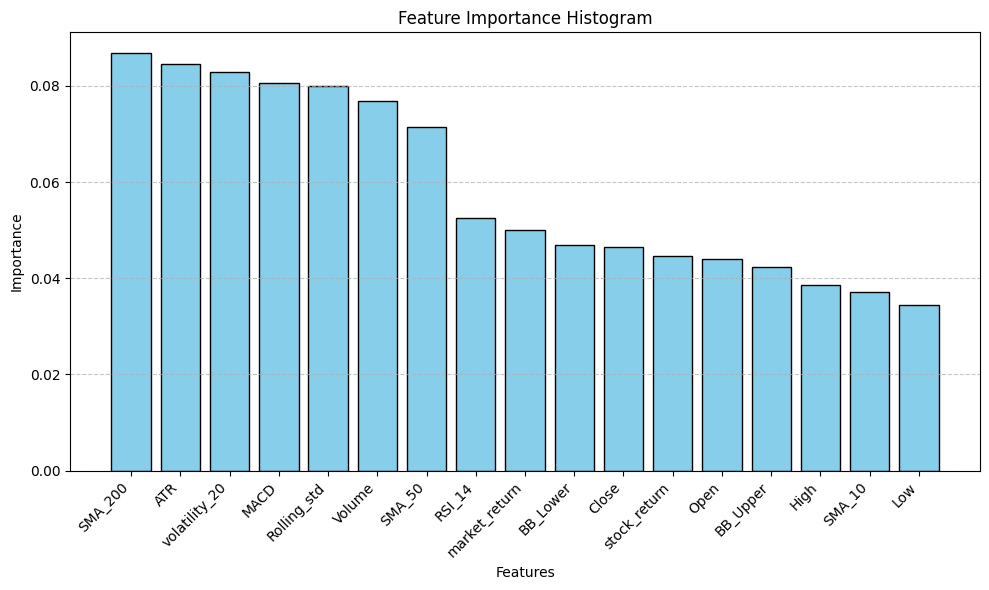

In [115]:
# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model[1].feature_importances_
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue', edgecolor='k')
plt.title('Feature Importance Histogram')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [116]:
print(feature_importance_df)

          Feature  Importance
9         SMA_200    0.086780
16            ATR    0.084487
10  volatility_20    0.082857
12           MACD    0.080488
13    Rolling_std    0.079988
4          Volume    0.076745
8          SMA_50    0.071357
11         RSI_14    0.052436
6   market_return    0.050040
15       BB_Lower    0.046863
0           Close    0.046566
5    stock_return    0.044690
3            Open    0.043996
14       BB_Upper    0.042359
1            High    0.038577
7          SMA_10    0.037226
2             Low    0.034546


#### Feature Selection and Hyperparameter fine-tuning

In [117]:
# Select the top 5 most important features based on feature importance
top_features = feature_importance_df.nlargest(5, 'Importance')['Feature']
X_train = X_train[top_features]
X_test = X_test[top_features]

# Hyperparameter fine-tuning with top 5 features
rf_param_grod = { 
        "model__n_estimators": [3, 5],              # tiny forest
        "model__max_depth": [1, 2],                 # decision stumps or near-stumps
        "model__min_samples_split": [100, 200],     # very hard to split
        "model__min_samples_leaf": [50, 100],       # very large leaves
        "model__max_features": [0.2],               # very limited feature usage
    }

rf_pipeline = Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ]
    )

rf_results = train_with_cv(
    X_train=X_train,
    y_train=y_train,
    n_splits=5,
    pipeline=rf_pipeline,
    param_grid=rf_param_grod
)

rf_model = rf_results["model"]
rf_best_params = rf_results["best_params"]
train_mse = rf_results["MSE_train"]
val_mse = rf_results["MSE"]


print("\033[1mHyperparameter fine-tuning using GridSearch and CV\n\033[0mBest Hyperparameters:")
print
print(rf_best_params)
print("\n\033[1mFeature Selection using Feature importance analysis\n\033[0mSelected Features:")
print(X_train.columns)

print("\n\033[1mCross-Validation Results after hyperparameter fine-tuning and feature selection\033[0m")
print("Train MSE: ",round(train_mse,5))
print("Val MSE: ",round(val_mse,5))
print("Val MSE/Train MSE Ratio: ", round(val_mse/train_mse,2))
print("\n\033[1mAnalysis\033[0m")
print(f"Val MSE/Train MSE Ratio: {round(val_mse/train_mse,2)} showes a moderate overfitting")
print(f"Also, Val MSE: {round(val_mse,5)} is decreased after hyperparameter fine-tuning.")

Hyperparameter fine-tuning using GridSearch and CV
Best Hyperparameters:
{'model__max_depth': 2, 'model__max_features': 0.2, 'model__min_samples_leaf': 50, 'model__min_samples_split': 200, 'model__n_estimators': 3}

Feature Selection using Feature importance analysis
Selected Features:
Index(['SMA_200', 'ATR', 'volatility_20', 'MACD', 'Rolling_std'], dtype='object')

Cross-Validation Results after hyperparameter fine-tuning and feature selection
Train MSE:  0.00027
Val MSE:  0.00041
Val MSE/Train MSE Ratio:  1.55

Analysis
Val MSE/Train MSE Ratio: 1.55 showes a moderate overfitting
Also, Val MSE: 0.00041 is decreased after hyperparameter fine-tuning.


### SVM for Regression (SVR)

In [118]:
svr_param_grod =  {
        "model__kernel": ["linear", "rbf"],
        "model__C": [0.1, 1.0, 10.0, 100.0],
        "model__epsilon": [0.0001, 0.001, 0.01, 0.05],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
    }

svr_pipeline = Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("model", SVR()),
        ]
    )

svr_results = train_with_cv(
    X_train=X_train,
    y_train=y_train,
    n_splits=5,
    pipeline=svr_pipeline,
    param_grid=svr_param_grod
)

svr_model = svr_results["model"]
svr_best_params = svr_results["best_params"]
train_mse = svr_results["MSE_train"]
val_mse = svr_results["MSE"]

print("Cross-Validation Results:")
print("Train MSE: ",round(train_mse,5))
print("Val MSE: ",round(val_mse,5))
print("Val MSE/Train MSE Ratio: ", round(val_mse/train_mse,2))
print("Base Hyperparameters:")
print(svr_best_params)

Cross-Validation Results:
Train MSE:  0.00026
Val MSE:  0.00044
Val MSE/Train MSE Ratio:  1.66
Base Hyperparameters:
{'model__C': 0.1, 'model__epsilon': 0.01, 'model__gamma': 0.01, 'model__kernel': 'rbf'}


###  Ordinary Least Squares (OLS) regression

In [119]:
def train_ols_with_timeseries_cv(X, y, n_splits=5):
    
    tscv = TimeSeriesSplit(n_splits=n_splits)

    mse_list = []
    r2_list = []
    da_list = []
    # Run KFold CV to get the best model based on validation MSE
    for train_idx, val_idx in tscv.split(X):
        # 1: Split train/validation
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 2: Scale features
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)

        # 3: Train OLS model on training fold
        ols_model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()

        # 4: Predict on validation fold
        X_val_scaled = scaler.transform(X_val)
        y_pred = ols_model.predict(sm.add_constant(X_val_scaled))

        # 5: Evaluate metrics on validation fold
        mse = mean_squared_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        da = directional_accuracy(y_val, y_pred)

        # Store fold evaluation metrics
        mse_list.append(mse)
        r2_list.append(r2)
        da_list.append(da)

    # Fit scaler on entire training data and transform X for final model fitting
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit ols_model on entire training data 
    ols_model = sm.OLS(y, sm.add_constant(X_scaled)).fit()

    # Evaluate average CV metrics across folds
    avg_mse = np.mean(mse_list)
    avg_r2 = np.mean(r2_list)
    avg_da = np.mean(da_list)

    return {
        "model": ols_model,
        "model_summary": ols_model.summary(),
        "MSE": avg_mse,
        "R2": avg_r2,
        "DA": avg_da,
        "scaler": scaler
    }

def evaluate_ols_model(model, X_test, y_test, scaler):
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(sm.add_constant(X_test_scaled))

    metrics = {
        "test_mse": mean_squared_error(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
        "test_da": directional_accuracy(y_test, y_pred),
    }

    return y_pred, metrics

In [120]:
ols_results = train_ols_with_timeseries_cv(
    X=X_train,
    y=y_train,
    n_splits=5,
)

print("Cross-Validation Results:")
print({
    "MSE": ols_results["MSE"],
    "R2": ols_results["R2"],
    "DA": ols_results["DA"],
})

print(ols_results['model_summary'])

Cross-Validation Results:
{'MSE': np.float64(0.0005258562228541623), 'R2': np.float64(-0.38327671331063035), 'DA': np.float64(0.4880000000000001)}
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.306
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.259
Time:                        12:44:02   Log-Likelihood:                 1529.6
No. Observations:                 604   AIC:                            -3047.
Df Residuals:                     598   BIC:                            -3021.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.

**Interpretation of Coefficient Significance**

The coefficient significance in the OLS regression is assessed the p-values associated with each predictor, which test the null hypothesis that the true coefficient is equal to zero (i.e., the feature has no effect on the target variable). In the reported results, only variables x3 (p = 0.047) and x5 (p = 0.033) are statistically significant at the conventional 5% level, indicating that these features have a meaningful linear relationship with next-day stock returns. Specifically, the negative coefficient of x3 suggests an inverse relationship with the target, while the positive coefficient of x5 indicates a direct relationship. In contrast, the remaining variables (x1, x2, x4) exhibit high p-values (> 0.05), implying that their estimated effects are not statistically distinguishable from zero and are likely driven by noise rather than true signal. Furthermore, the overall model significance is weak, as indicated by the non-significant F-statistic (p = 0.259), suggesting that the model, as a whole, lacks explanatory power. This is consistent with the very low R² value (0.011), reinforcing the conclusion that most predictors do not contribute meaningfully to explaining variation in stock returns.

## Evaluation

### Baseline Predictors

In [121]:
def baseline_zero(X):
    return np.zeros(len(X))

def baseline_mean(X, y_train_mean):
    return np.full(len(X), y_train_mean)

def evaluate_baseline(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "DA": directional_accuracy(y_true, y_pred),
    }

# Baseline 1: Zero
y_pred_zero = baseline_zero(X_test)
baseline_zero_metrics = evaluate_baseline(y_test, y_pred_zero)

# Baseline 2: Mean
y_train_mean = y_train.mean()
y_pred_mean = baseline_mean(X_test, y_train_mean)
baseline_mean_metrics = evaluate_baseline(y_test, y_pred_mean)

### CV results

This is the result based on Timeseries Cross Validation for checking the robustness of models.

In [122]:
cv_results = pd.DataFrame([
    {
        "Model": "OLS",
        "MSE": ols_results["MSE"],
        "R2": ols_results["R2"],
        "DA": ols_results["DA"]        
    },
    {
        "Model": "SVM",
        "MSE": svr_results["MSE"],
        "R2": svr_results["R2"],
        "DA": svr_results["DA"],
    },
    {
        "Model": "Random Forest",
        "MSE": rf_results["MSE"],
        "R2": rf_results["R2"],
        "DA": rf_results["DA"],
    }
])

print("Average error of timeseries cross-validation")
print(cv_results)

Average error of timeseries cross-validation
           Model       MSE        R2     DA
0            OLS  0.000526 -0.383277  0.488
1            SVM  0.000440 -0.074223  0.498
2  Random Forest  0.000415 -0.030471  0.504


### Test Result

This is result based on 25% test set for comparion between different models.

In [123]:
# RF test evaluation
rf_test_pred, rf_test_metrics = evaluate_model(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
)
# SVR test evaluation
svr_test_pred, svr_test_metrics = evaluate_model(
    model=svr_model,
    X_test=X_test,
    y_test=y_test,
)

# OLS test evaluation
ols_test_pred, ols_test_metrics = evaluate_ols_model(
    model=ols_results["model"],
    X_test=X_test,
    y_test=y_test,
    scaler=ols_results["scaler"]
)

In [124]:
results = pd.DataFrame([
    {
        "Model": "OLS",
        "MSE": ols_test_metrics["test_mse"],
        "R2": ols_test_metrics["test_r2"],
        "DA": ols_test_metrics["test_da"]        
    },
    {
        "Model": "SVM",
        "MSE": svr_test_metrics["test_mse"],
        "R2": svr_test_metrics["test_r2"],
        "DA": svr_test_metrics["test_da"],
    },
    {
        "Model": "Random Forest",
        "MSE": rf_test_metrics["test_mse"],
        "R2": rf_test_metrics["test_r2"],
        "DA": rf_test_metrics["test_da"],
    },
    {
        "Model": "Baseline (Mean)",
        "MSE": baseline_mean_metrics["MSE"],
        "R2": baseline_mean_metrics["R2"],
        "DA": baseline_mean_metrics["DA"],
    },
])
print("Final Test Set Comparison:")
print(results)

Final Test Set Comparison:
             Model       MSE        R2        DA
0              OLS  0.000798 -0.080089  0.504950
1              SVM  0.000742 -0.004278  0.554455
2    Random Forest  0.000794 -0.074686  0.529703
3  Baseline (Mean)  0.000745 -0.008396  0.559406


## Other Assets

### JNJ

In [ ]:
# Average error of timeseries cross-validation
#            Model       MSE        R2     DA
# 0            OLS  0.000189 -0.142953  0.492
# 1            SVM  0.000173  0.004307  0.498
# 2  Random Forest  0.000175 -0.007738  0.456

# Final Test Set Comparison:
#              Model       MSE        R2        DA
# 0              OLS  0.000334 -0.020833  0.460396
# 1              SVM  0.000325  0.005447  0.485149
# 2    Random Forest  0.000331 -0.011761  0.480198
# 3  Baseline (Mean)  0.000328 -0.002422  0.519802

### MSFT

In [ ]:
# Average error of timeseries cross-validation
#            Model       MSE        R2     DA
# 0            OLS  0.000379 -0.164136  0.486
# 1            SVM  0.000342 -0.016995  0.490
# 2  Random Forest  0.000340 -0.005040  0.564

# Final Test Set Comparison:
#              Model       MSE        R2        DA
# 0              OLS  0.000653 -0.044355  0.514851
# 1              SVM  0.000631 -0.010010  0.524752
# 2    Random Forest  0.000658 -0.053004  0.430693
# 3  Baseline (Mean)  0.000625 -0.000566  0.569307

### PG

In [ ]:
# Average error of timeseries cross-validation
#            Model       MSE        R2     DA
# 0            OLS  0.000227 -0.216693  0.460
# 1            SVM  0.000204 -0.016402  0.496
# 2  Random Forest  0.000204 -0.026478  0.452

# Final Test Set Comparison:
#              Model       MSE        R2        DA
# 0              OLS  0.000306 -0.008249  0.490099
# 1              SVM  0.000305 -0.003655  0.500000
# 2    Random Forest  0.000311 -0.023420  0.495050
# 3  Baseline (Mean)  0.000304 -0.001261  0.534653

### KO

In [ ]:
# Average error of timeseries cross-validation
#            Model       MSE        R2     DA
# 0            OLS  0.000187 -0.548012  0.506
# 1            SVM  0.000149 -0.009057  0.514
# 2  Random Forest  0.000149 -0.009619  0.490

# Final Test Set Comparison:
#              Model       MSE        R2        DA
# 0              OLS  0.000492 -0.097874  0.514851
# 1              SVM  0.000447  0.002316  0.574257
# 2    Random Forest  0.000451 -0.005960  0.480198
# 3  Baseline (Mean)  0.000448 -0.000943  0.519802